# HW04 —  Линейная ригрессия

## Используемый датасет
В данной работе оспользовался [набор данных](https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars) Price of Used Toyota Corolla Cars.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score,
    mean_absolute_percentage_error
)

sns.set_style('darkgrid')
df = pd.read_csv('ToyotaCorolla.csv')

# Проверка загрузки файла
display(df.head())
display(df.sample(5))
display(df.tail())

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
552,556,TOYOTA Corolla 1.6 VVT-i Linea Sol 4/5-Doors,12950,49,8,2000,41636,Petrol,110,1,...,1,1,1,0,0,0,0,1,0,1
974,979,TOYOTA Corolla 1.6 16V SEDAN LINEA TERRA 4/5-D...,10450,60,9,1999,47060,Petrol,110,0,...,0,1,0,0,0,0,0,0,0,0
166,168,TOYOTA Corolla 1.6 16V VVT I 5DR EXEC 4/5-Doors,19950,14,7,2003,5459,Petrol,110,1,...,1,1,0,1,1,1,1,0,0,0
621,625,TOYOTA Corolla 2.0 DSL HATCHB LINEA TERRA 2/3-...,6900,60,9,1999,139800,Diesel,72,0,...,0,1,0,0,0,1,0,0,0,0
1172,1178,TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-D...,7750,78,3,1998,95651,Petrol,110,1,...,0,1,1,0,0,1,0,1,0,1


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0
1435,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,5,1998,1,Petrol,110,0,...,0,1,0,0,0,0,0,0,0,0


In [2]:
print(df.shape)
df.info()

(1436, 39)
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight        

In [3]:
# статистика по числовым и строчным столбцам
display(df.describe())
display(df.describe(include='string'))

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,Model,Fuel_Type,Color
count,1436,1436,1436
unique,319,3,10
top,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,Petrol,Grey
freq,109,1264,301


In [4]:
# Проверка пропусков
print(df.isnull().sum())

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


## EDA и предобработка

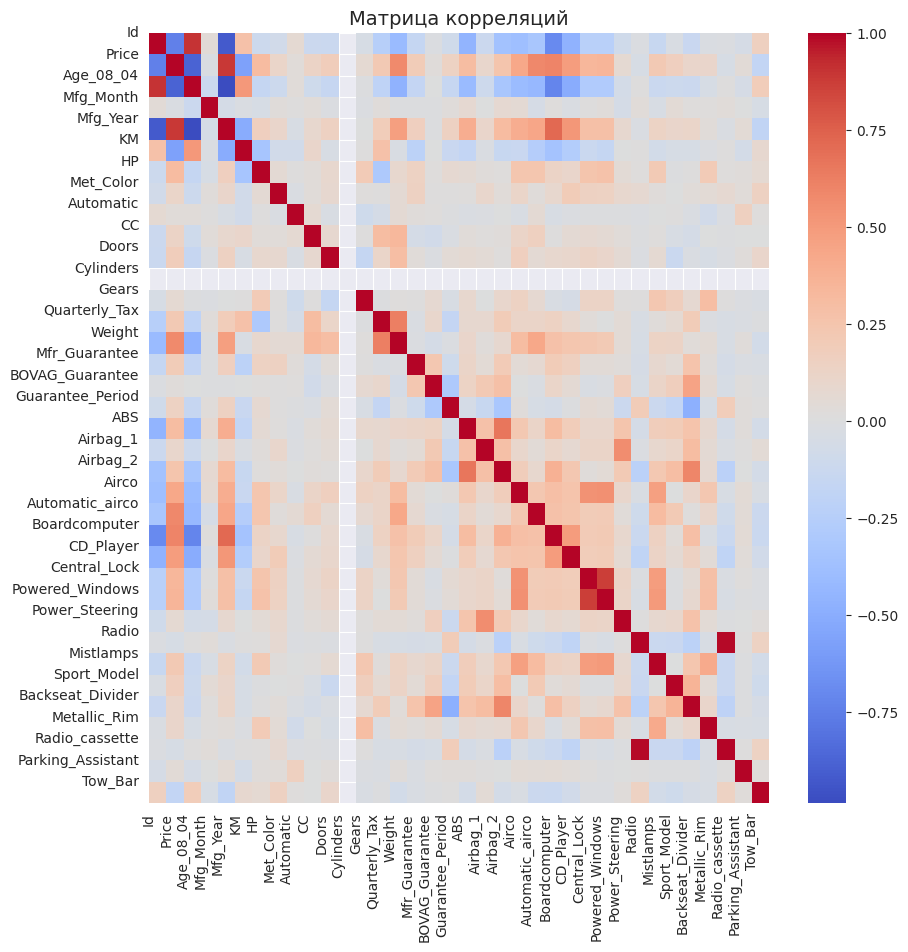

Price                1.000000
Mfg_Year             0.983301
Boardcomputer        0.910541
Automatic_airco      0.863716
CD_Player            0.853608
Weight               0.801586
Airco                0.762274
ABS                  0.641832
Powered_Windows      0.599467
Central_Lock         0.592145
HP                   0.506422
Airbag_2             0.504299
Mistlamps            0.452922
Mfr_Guarantee        0.405981
Doors                0.378109
Quarterly_Tax        0.345277
CC                   0.244645
Sport_Model          0.242512
Backseat_Divider     0.232667
Met_Color            0.225962
Airbag_1             0.177762
Metallic_Rim         0.174109
Guarantee_Period     0.169280
Power_Steering       0.129728
Parking_Assistant    0.066793
Gears                0.063755
BOVAG_Guarantee     -0.018127
Mfg_Month           -0.052903
Automatic           -0.065617
Radio               -0.224715
Radio_cassette      -0.225125
Tow_Bar             -0.508013
KM                  -0.832137
Id        

In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f')
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Матрица корреляций', fontsize=14)
plt.show()

print(corr.corr()['Price'].sort_values(ascending=False))

По информации о датасете, приведенной выше, можно сделать выводы:
1. `Id` можно удалить, т.к. она не важна
2. `Fuel_type`, `Color` колонки можно закодировать. Используем One-hot-Encoding
3. `Cylinders` имеет одинаковые занчения для всех. Можно удалить
4. У `Mfg_Year` и `Age_08_04` наблюдается мультикаллиниарность. Можно оставить один признак, например `Mfg_Year`
5. Слабая корреляция наблюдяется у `Parking_Assistant`, `Gears`, `Mfg_Month`, `Automatic` - их можно удалить.

Пропусков нет.

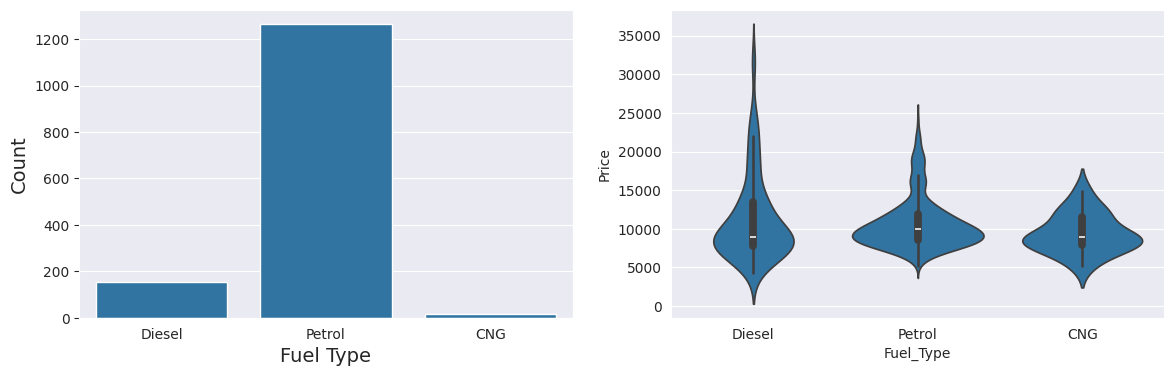

In [6]:
fuel = Counter(df['Fuel_Type'])
labels = fuel.keys()
sizes = fuel.values()

f, axes = plt.subplots(1, 2, figsize=(14,4))
sns.countplot(data=df, x='Fuel_Type', ax=axes[0])
axes[0].set_xlabel('Fuel Type', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()
sns.violinplot(x='Fuel_Type', y='Price', data=df, ax=axes[1])
plt.show()

### Подготовка данных

In [7]:
# Удаляем некоторые колонки
df = df.drop(columns=['Id', 'Cylinders', 'Age_08_04', 'Parking_Assistant', 'Gears', 'Mfg_Month', 'Automatic', 'Model'])

# One-Hot-Encoding
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Color'], prefix=['Fuel', 'Color'])
display(df_encoded.sample(5))


,Price,Mfg_Year,KM,HP,Met_Color,CC,Doors,Quarterly_Tax,Weight,Mfr_Guarantee,...,Color_Beige,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
86,14900,2002,7000,97,1,1400,5,85,1100,0,...,False,False,False,False,False,False,True,False,False,False
1071,7750,1998,151300,72,1,2000,5,185,1150,0,...,False,True,False,False,False,False,False,False,False,False
1274,9000,1998,74196,110,0,1600,5,85,1075,0,...,False,False,True,False,False,False,False,False,False,False
669,9750,1999,105942,86,0,1300,5,69,1040,1,...,False,False,False,False,False,True,False,False,False,False
1293,8500,1998,71825,110,0,1600,5,85,1075,0,...,False,False,False,False,True,False,False,False,False,False


In [8]:
# Разделим датасет на признаки и таргет
X = df_encoded.drop(columns='Price')
y = df_encoded['Price']

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_test.shape)

(288, 41)
(1148,)


In [9]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение модели

In [10]:
# Обучим базовую модель линейной регрессии
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# MAE метрика
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# MSE метрика
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

# RMSE метрика
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# MAPE
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2%}")

# R^2 метрика
print(f"R^2: {r2_score(y_test, y_pred):.2f}")

MAE: 1018.82
MSE: 6901197.75
RMSE: 2627.01
MAPE: 9.84%
R^2: 0.47


Можно теперь оценить качество базовой модели:

1. R² = 0.47. Модель объясняет 47% дисперсии цены. Это средний результат, Остальные 53% дисперсии не объяснены линейными связями.
2. MAPE < 10%. Неплохой результат, однако для лучшего результата необходимо рассмотреть другую модель, т.к. некоторые признаки могут не поддаваться линейным связям.
3. MAE = 1019. Типичная ошибка около 1000 денежных единиц. При средней цене в 10000 - это не плохой, но и отличный результат.
4. RMSE = 2627. Больше MAE в 2.5 раза, что указывает на наличие крупных выбросов, несколько предсказаний сильно ошибаются.

Базовая модель линейной регрессии в целом подходит, но справляется не очень хорошо, потому что имеются сильные выбросы и некоторые признаки имеют нелинейную зависимость.

Теперь перейдем к Lasso.

In [11]:
param_grid = {'alpha': [0.001, 0.01, 0.5, 1, 10, 50, 100, 200, 500, 1000]}
lasso = Lasso(random_state=42, max_iter=50000, tol=0.001)

grid_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

best_lasso = grid_lasso.best_estimator_

print(f"Лучший alpha: {best_lasso}")
print(f"Лучший R²: {grid_lasso.best_score_:.3f}")

# Обучим Lasso на лучшем alpha
y_pred_lasso = best_lasso.predict(X_test_scaled)

print('Метрики обучения на Lasso:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_lasso):.2%}")
print(f"R^2: {r2_score(y_test, y_pred_lasso):.2f}")

Лучший alpha: Lasso(alpha=50, max_iter=50000, random_state=42, tol=0.001)
Лучший R²: 0.888
Метрики обучения на Lasso:
MAE: 901.95
MSE: 1453266.75
RMSE: 1205.52
MAPE: 8.91%
R^2: 0.89


Оценим качество модели на Lasso:

Лучший параметр `alpha`, найденный с помощью GridSearch кросс-валидации, равен 50.

Данные значения лучше, чем обучение на базовой модели. Следовательно, Lasso хорошо справился с выборо параметров и показания модели улучшились. Особенно сильно уменьшились метрики `RMSE` (проблема с выбросами практически решена) и `R^2`(теперь объясняем больше процентов дисперсии), а также на один процент уменьшилась `MAPE`. Можно сделать вывод, что данная модель лучше подходит для задачи.

Напоследок, проверим Ridge.

In [12]:
param_grid_ridge = {'alpha': [0.001, 0.01, 0.5, 1, 10, 50, 100, 200]}
ridge = Ridge(random_state=42, max_iter=50000)

grid_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

best_ridge = grid_ridge.best_estimator_

print(f"Лучший alpha: {best_ridge}")
print(f"Лучший R²: {grid_lasso.best_score_:.3f}")

# Обучим Ridge на лучшем alpha
y_pred_ridge = best_ridge.predict(X_test_scaled)

print('Метрики обучения на Ridge:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_ridge):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge):.2%}")
print(f"R^2: {r2_score(y_test, y_pred_ridge):.2f}")

Лучший alpha: Ridge(alpha=10, max_iter=50000, random_state=42)
Лучший R²: 0.888
Метрики обучения на Ridge:
MAE: 981.06
MSE: 3510717.75
RMSE: 1873.69
MAPE: 9.57%
R^2: 0.73


Сравним Lasso и Ridge:

Ridge показал следующие результаты:
- R² = 0.73 (против 0.89 у Lasso)
- MAPE = 9.57% (против 8.91% у Lasso)
- RMSE = 1874 (против 1206 у Lasso)

Ridge справился хуже Lasso по всем метрикам. Это объясняется тем, что:
1. В данных присутствуют признаки, которые не улучшают, а ухудшают качество предсказаний.
2. Ridge, в отличие от Lasso, не обнуляет коэффициенты, а только сжимает их, сохраняя все признаки в модели.
3. Lasso успешно исключил шумы (обнулил их коэффициенты), что привело к более высокой обобщающей способности.

Таким образом, для задачи Lasso предпочтительнее Ridge, так как он обеспечивает лучшее качество предсказаний и автоматический отбор значимых признаков.

## Итоги

По проведенному анализу можно сделать вывод, что лучше всего спраилась модель с Lasso.

#### Какие метрики вы использовали для сравнения моделей?
В работе я использовал различные метрики с целью обучения и сравнения результатов. В качестве итога можно выделить основные: `MAE`, `RMSE`, `MAPE` и `R^2`, потому что:
- `MAE` показывает типичную ошибку модели в единицах целевой переменной и легко интерпретируется.
- `RMSE` сильнее штрафует за большие ошибки и помогает выявить наличие выбросов (которые были).
- `MAPE` позволяет оценить качество в относительных величинах, независимо от масштаба данных.
- `R^2` показывает, какую долю дисперсии целевой переменной объясняет модель.

#### На какой части выборки вы считали метрики?
На тестовой выборке, которая составляет 20% от всей выборки. Такой подход позволяет объективно оценить способность модели к обобщению данных.

#### Какая модель по итогу справилась лучше?
Лучше всех справилась Lasso, потому что в наборе данных присутствовали признаки-шумы, которые ухудшали работу модели, и Lasso обнулил их, в отличе от Ridge, который в любом случае оставляет все признаки без их обнуления.

#### Насколько хорошие получились результаты?
В целом, результаты можно оценить как хорошие:
- `R^2` = 0.89. Модель объясняет 89% дисперсии целевой переменной, что весьма высокий показатель.
- `MAPE` = 8.91% показывает, что в среднем модель ошибается менее чем на 9%, что можно оценить как хороший показатель.
- `MAE` = 902 при средней цене ~10000 единиц означает ошибку около 9% от среднего значения.
- `RMSE` = 1206 не сильно превышает MAE, что указывает на отсутствие критических выбросов.

#### Чем докажете, что ваша модель не переобучилась?
При сравнении метрика на train и test(`R^2` 0.888 vs 0.89) можно увидеть, что значенителького падения качества нет. Также, `RMSE` и `MAE` имеют небольшие различия в значениях (1206 vs 902), что указывает на отсутствие редких, но очень сильных ошибок - признака переобучения.